# World Happiness Report 2026 — Exploratory & Statistical Analysis

**Analytical question:**
What socio-economic factors are associated with differences in life satisfaction across countries, and how have these relationships evolved over time (2011–2025)?

**Sub-questions:**
1. How is life evaluation distributed across countries, and how skewed is it?
2. Which factors correlate most strongly with life evaluation — and are those correlations statistically significant?
3. When all six factors are considered together (multiple regression), which ones independently matter most?
4. How has the global average changed since 2011, and is the trend statistically meaningful?
5. Which countries have improved or declined the most, and which are the most volatile?

**Data source:** World Happiness Report 2026, Data for Figure 2.1 (official, free release).
168 countries, years 2011–2025 (no data for 2013).

**Notebook structure:**
1. Data understanding
2. Data cleaning
3. EDA — 2025 snapshot
4. Correlation & statistical significance
5. Multiple regression — controlling for all factors at once
6. Trends over time (2011–2025) + trend significance
7. Biggest movers: which countries changed the most
8. Volatility: which countries are most/least stable
9. Key insights & limitations


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

RAW_PATH = "../data/raw/WHR26_Data_Figure_2_1_Data_for_Figure_2.csv"
PROCESSED_PATH = "../data/processed/happiness_clean.csv"


## 1. Data Understanding

In [2]:
df_raw = pd.read_csv(RAW_PATH, encoding="latin-1")
print(df_raw.shape)
df_raw.head()


(2116, 28)


,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,...,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 2116 entries, 0 to 2115
Data columns (total 28 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Year                                        2116 non-null   int64  
 1   Rank                                        2116 non-null   int64  
 2   Country name                                2116 non-null   str    
 3   Life evaluation (3-year average)            2116 non-null   float64
 4   Lower whisker                               1022 non-null   float64
 5   Upper whisker                               1022 non-null   float64
 6   Explained by: Log GDP per capita            1019 non-null   float64
 7   Explained by: Social support                1019 non-null   float64
 8   Explained by: Healthy life expectancy       1016 non-null   float64
 9   Explained by: Freedom to make life choices  1017 non-null   float64
 10  Explained by: Generosit

In [4]:
# Drop fully-empty trailing columns (artifact of the CSV export)
df = df_raw.dropna(axis=1, how="all").copy()
df.columns.tolist()


['Year',
 'Rank',
 'Country name',
 'Life evaluation (3-year average)',
 'Lower whisker',
 'Upper whisker',
 'Explained by: Log GDP per capita',
 'Explained by: Social support',
 'Explained by: Healthy life expectancy',
 'Explained by: Freedom to make life choices',
 'Explained by: Generosity',
 'Explained by: Perceptions of corruption',
 'Dystopia + residual']

In [5]:
df.describe()


,Year,Rank,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
count,2116.000,2116.000,2116.000,1022.000,1022.000,1019.000,1019.000,1016.000,1017.000,1019.000,1018.000,1013.000
mean,2018.220,76.191,5.466,5.436,5.665,1.266,1.097,0.553,0.609,0.147,0.145,1.737
std,4.250,43.845,1.124,1.141,1.107,0.464,0.358,0.230,0.212,0.084,0.119,0.658
min,2011.000,1.000,1.364,1.301,1.427,0.000,0.000,0.000,0.000,0.000,0.000,-0.295
25%,2015.000,38.000,4.605,4.620,4.868,0.944,0.865,0.390,0.471,0.088,0.063,1.305
50%,2018.000,76.000,5.480,5.592,5.812,1.304,1.140,0.560,0.602,0.134,0.113,1.765
75%,2022.000,114.000,6.321,6.290,6.487,1.636,1.382,0.712,0.735,0.196,0.181,2.178
max,2025.000,158.000,7.856,7.780,7.904,2.209,1.840,1.238,1.147,0.570,0.587,3.482


In [6]:
missing = df.isna().sum()
missing[missing > 0]


Lower whisker                                 1094
Upper whisker                                 1094
Explained by: Log GDP per capita              1097
Explained by: Social support                  1097
Explained by: Healthy life expectancy         1100
Explained by: Freedom to make life choices    1099
Explained by: Generosity                      1097
Explained by: Perceptions of corruption       1098
Dystopia + residual                           1103
dtype: int64

In [7]:
# Panel balance: how many years of data does each country have? (max possible = 14, since 2013 is missing)
coverage = df.groupby("Country name")["Year"].nunique().sort_values()
print("Countries with full 14-year coverage:", (coverage == coverage.max()).sum())
print("Countries with fewer than 5 years of data:", (coverage < 5).sum())
coverage.head(10)


Countries with full 14-year coverage: 129
Countries with fewer than 5 years of data: 9


Country name
Guyana               1
Cuba                 1
Puerto Rico          2
Maldives             2
Djibouti             3
Suriname             3
Eswatini             4
Oman                 4
Somaliland Region    4
South Sudan          5
Name: Year, dtype: int64

In [8]:
# Duplicate check
print("Duplicate (country, year) rows:", df.duplicated(subset=["Country name", "Year"]).sum())


Duplicate (country, year) rows: 0


**Notes:**
- The dataset is an unbalanced panel — not every country has data for every year (newer entrants like Kosovo, or countries with limited Gallup polling, have fewer years).
- No duplicate country-year rows.
- No missing values in the core numeric columns after dropping the empty trailing columns — the raw export just has stray empty columns from Excel formatting.


## 2. Data Cleaning

In [9]:
df = df.rename(columns={
    "Life evaluation (3-year average)": "life_evaluation",
    "Lower whisker": "ci_lower",
    "Upper whisker": "ci_upper",
    "Explained by: Log GDP per capita": "gdp_per_capita",
    "Explained by: Social support": "social_support",
    "Explained by: Healthy life expectancy": "healthy_life_expectancy",
    "Explained by: Freedom to make life choices": "freedom",
    "Explained by: Generosity": "generosity",
    "Explained by: Perceptions of corruption": "corruption_perception",
    "Dystopia + residual": "dystopia_residual",
    "Country name": "country",
    "Year": "year",
    "Rank": "rank",
})

factor_cols = [
    "gdp_per_capita", "social_support", "healthy_life_expectancy",
    "freedom", "generosity", "corruption_perception",
]

df.to_csv(PROCESSED_PATH, index=False)
df.head()


,year,rank,country,life_evaluation,ci_lower,ci_upper,gdp_per_capita,social_support,healthy_life_expectancy,freedom,generosity,corruption_perception,dystopia_residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041


## 3. Exploratory Analysis — 2025 Snapshot

In [10]:
df_2025 = df[df["year"] == 2025].sort_values("life_evaluation", ascending=False).reset_index(drop=True)
print(f"Mean: {df_2025['life_evaluation'].mean():.3f} | Median: {df_2025['life_evaluation'].median():.3f} | "
      f"Std: {df_2025['life_evaluation'].std():.3f} | Skew: {df_2025['life_evaluation'].skew():.3f}")
df_2025.head(10)


Mean: 5.650 | Median: 5.937 | Std: 1.138 | Skew: -0.609


,year,rank,country,life_evaluation,ci_lower,ci_upper,gdp_per_capita,social_support,healthy_life_expectancy,freedom,generosity,corruption_perception,dystopia_residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041
5,2025,6,Norway,7.242,7.156,7.327,2.057,1.626,0.983,1.092,0.157,0.413,0.913
6,2025,7,Netherlands,7.223,7.153,7.293,1.983,1.539,0.922,1.000,0.175,0.349,1.255
7,2025,8,Israel,7.187,7.119,7.254,1.867,1.606,0.925,0.863,0.139,0.196,1.592
8,2025,9,Luxembourg,7.063,6.971,7.154,2.162,1.465,0.981,1.056,0.111,0.382,0.907
9,2025,10,Switzerland,7.018,6.937,7.099,2.028,1.534,1.017,1.035,0.148,0.452,0.804


In [11]:
# A couple of countries have a missing factor value in 2025 (e.g. incomplete Gallup polling
# that year). Rather than silently letting it break the correlation/regression, flag and drop them.
missing_factor_rows = df_2025[df_2025[factor_cols].isna().any(axis=1)]
print("Countries excluded from factor-level analysis due to missing values:")
display(missing_factor_rows[["country"] + factor_cols])

df_2025_complete = df_2025.dropna(subset=factor_cols).copy()
print(f"\n{len(df_2025)} countries in 2025 -> {len(df_2025_complete)} with complete factor data")


Countries excluded from factor-level analysis due to missing values:


,country,gdp_per_capita,social_support,healthy_life_expectancy,freedom,generosity,corruption_perception
87,Tajikistan,1.180,1.476,0.783,NaN,0.085,0.336
108,State of Palestine,1.242,1.335,NaN,0.742,0.073,0.095



147 countries in 2025 -> 145 with complete factor data


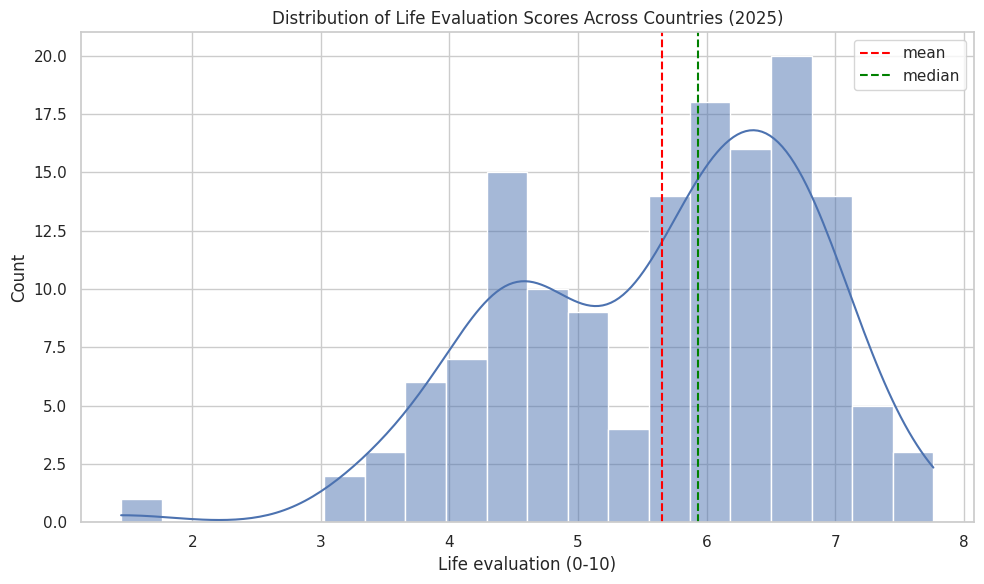

In [12]:
fig, ax = plt.subplots()
sns.histplot(df_2025["life_evaluation"], bins=20, kde=True, ax=ax)
ax.axvline(df_2025["life_evaluation"].mean(), color="red", linestyle="--", label="mean")
ax.axvline(df_2025["life_evaluation"].median(), color="green", linestyle="--", label="median")
ax.set_title("Distribution of Life Evaluation Scores Across Countries (2025)")
ax.set_xlabel("Life evaluation (0-10)")
ax.legend()
plt.tight_layout()
plt.savefig("../visuals/happiness_distribution_2025.png", dpi=150)
plt.show()


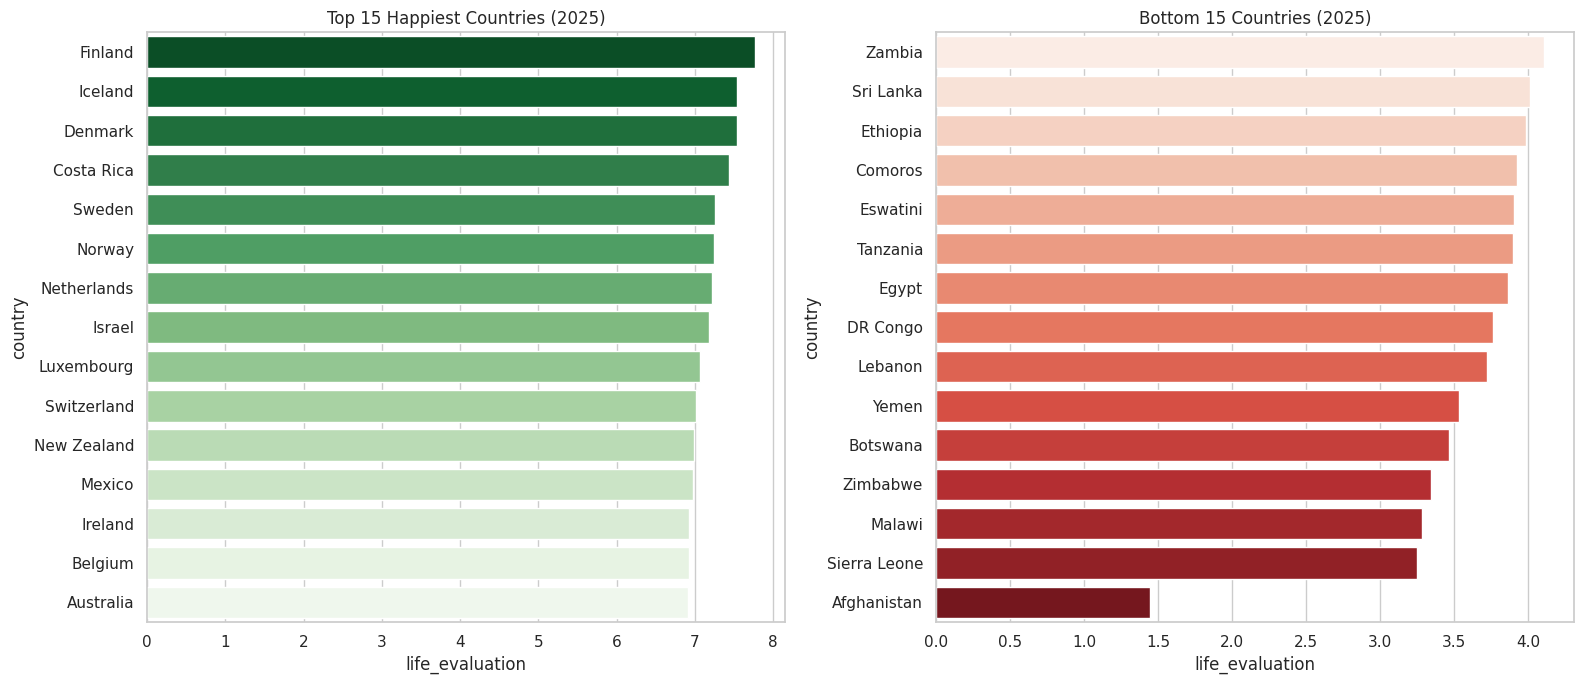

In [13]:
top15 = df_2025.head(15)
bottom15 = df_2025.tail(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.barplot(data=top15, y="country", x="life_evaluation", hue="country", ax=axes[0], palette="Greens_r", legend=False)
axes[0].set_title("Top 15 Happiest Countries (2025)")

sns.barplot(data=bottom15, y="country", x="life_evaluation", hue="country", ax=axes[1], palette="Reds", legend=False)
axes[1].set_title("Bottom 15 Countries (2025)")

plt.tight_layout()
plt.savefig("../visuals/top_bottom_countries_2025.png", dpi=150)
plt.show()


## 4. Correlation & Statistical Significance

In [14]:
# Pearson correlation + p-value for each factor (2025 cross-section)
results = []
for col in factor_cols:
    r, p = stats.pearsonr(df_2025_complete[col], df_2025_complete["life_evaluation"])
    results.append({"factor": col, "pearson_r": r, "p_value": p, "significant_at_0.05": p < 0.05})

corr_table = pd.DataFrame(results).sort_values("pearson_r", ascending=False).reset_index(drop=True)
corr_table


,factor,pearson_r,p_value,significant_at_0.05
0,social_support,0.812,0.000,True
1,gdp_per_capita,0.745,0.000,True
2,healthy_life_expectancy,0.679,0.000,True
3,freedom,0.638,0.000,True
4,corruption_perception,0.396,0.000,True
5,generosity,0.038,0.648,False


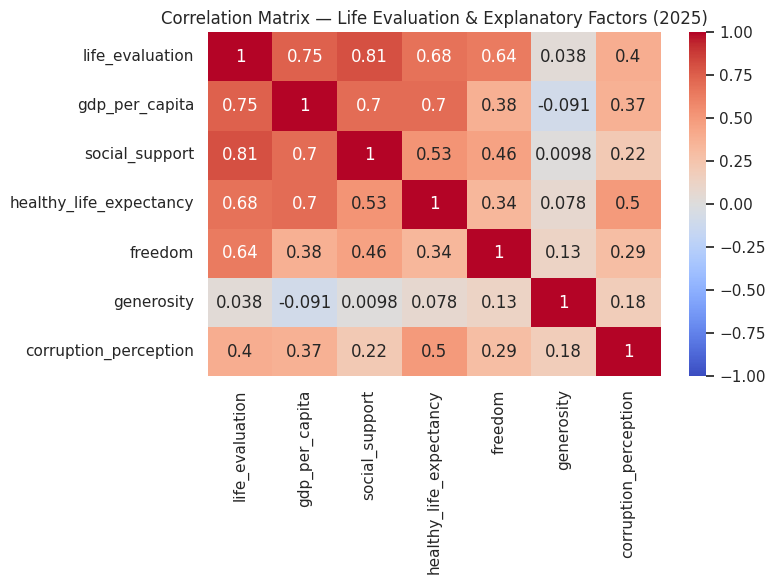

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df_2025_complete[["life_evaluation"] + factor_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation Matrix — Life Evaluation & Explanatory Factors (2025)")
plt.tight_layout()
plt.savefig("../visuals/factor_correlation_2025.png", dpi=150)
plt.show()


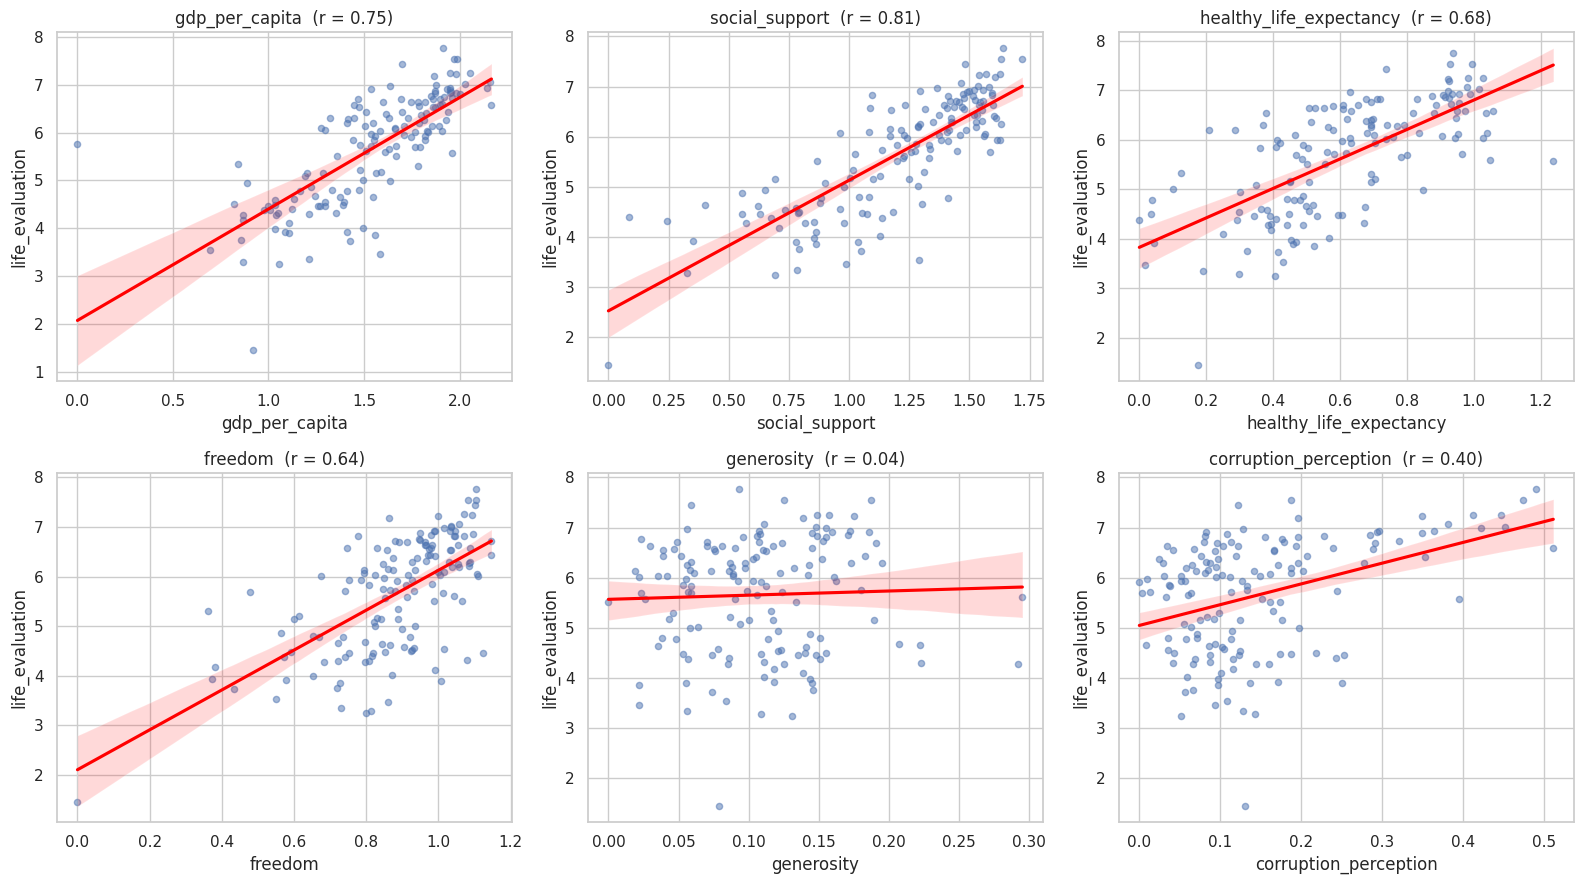

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, factor_cols):
    sns.regplot(data=df_2025_complete, x=col, y="life_evaluation", ax=ax,
                scatter_kws={"alpha": 0.5, "s": 20}, line_kws={"color": "red"})
    r = corr_table.loc[corr_table["factor"] == col, "pearson_r"].values[0]
    ax.set_title(f"{col}  (r = {r:.2f})")
plt.tight_layout()
plt.savefig("../visuals/happiness_vs_factors_2025.png", dpi=150)
plt.show()


**How to read this:** correlation alone can be misleading when factors are related to each other
(e.g. GDP and healthy life expectancy tend to move together). Section 5 controls for that by putting
all six factors into one regression model at the same time.


## 5. Multiple Regression — Controlling for All Factors at Once

In [17]:
X = df_2025_complete[factor_cols]
X = sm.add_constant(X)
y = df_2025_complete["life_evaluation"]

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:        life_evaluation   R-squared:                       0.827
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     109.8
Date:                Tue, 11 Aug 2026   Prob (F-statistic):           4.86e-50
Time:                        12:32:42   Log-Likelihood:                -97.545
No. Observations:                 145   AIC:                             209.1
Df Residuals:                     138   BIC:                             229.9
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [18]:
coef_table = (
    model.params.drop("const")
    .rename("coefficient")
    .to_frame()
    .assign(p_value=model.pvalues.drop("const"))
    .assign(significant=lambda d: d["p_value"] < 0.05)
    .sort_values("coefficient", ascending=False)
)
coef_table


,coefficient,p_value,significant
freedom,1.806,0.000,True
social_support,1.442,0.000,True
healthy_life_expectancy,0.915,0.000,True
corruption_perception,0.566,0.203,False
gdp_per_capita,0.489,0.011,True
generosity,-0.306,0.707,False


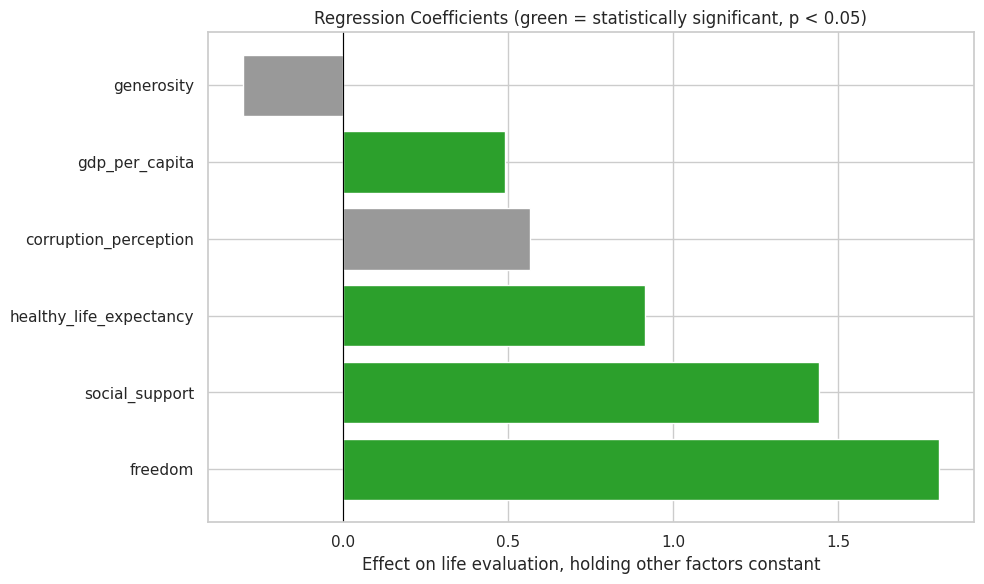

In [19]:
fig, ax = plt.subplots()
colors = coef_table["significant"].map({True: "#2ca02c", False: "#999999"})
ax.barh(coef_table.index, coef_table["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Regression Coefficients (green = statistically significant, p < 0.05)")
ax.set_xlabel("Effect on life evaluation, holding other factors constant")
plt.tight_layout()
plt.savefig("../visuals/regression_coefficients.png", dpi=150)
plt.show()


**Interpretation template (replace with your own numbers after running):**
- Model R² tells you what share of the variance in life evaluation is jointly explained by the six factors.
- A factor with a high *simple correlation* (Section 4) but a small/insignificant *regression coefficient* here likely overlaps with another factor (multicollinearity) rather than having its own independent effect.
- Focus your narrative on factors that are significant (p < 0.05) in the regression — those are the ones you can defend as independently associated with happiness.


## 6. Trends Over Time (2011–2025)

In [20]:
global_trend = df.groupby("year")["life_evaluation"].agg(["mean", "std", "count"]).reset_index()
global_trend


,year,mean,std,count
0,2011,5.392,1.099,156
1,2012,5.419,1.102,156
2,2014,5.376,1.145,158
3,2015,5.382,1.142,157
4,2016,5.354,1.131,155
5,2017,5.376,1.120,156
6,2018,5.407,1.113,156
7,2019,5.473,1.112,153
8,2020,5.533,1.074,149
9,2021,5.554,1.087,146


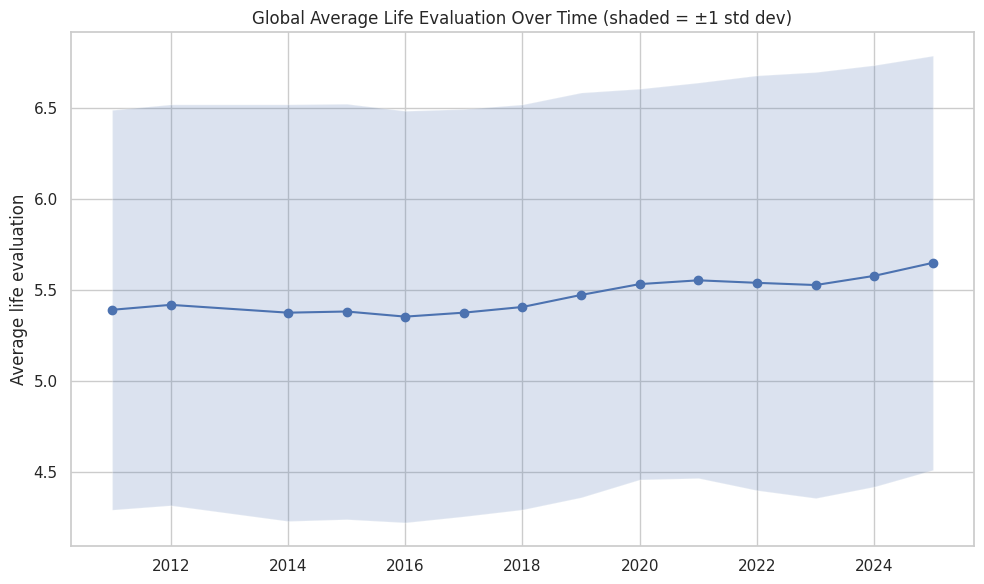

In [21]:
fig, ax = plt.subplots()
ax.plot(global_trend["year"], global_trend["mean"], marker="o")
ax.fill_between(global_trend["year"],
                 global_trend["mean"] - global_trend["std"],
                 global_trend["mean"] + global_trend["std"],
                 alpha=0.2)
ax.set_title("Global Average Life Evaluation Over Time (shaded = ±1 std dev)")
ax.set_ylabel("Average life evaluation")
plt.tight_layout()
plt.savefig("../visuals/global_trend.png", dpi=150)
plt.show()


In [22]:
# Is the trend statistically significant? Simple linear regression of global mean on year
slope, intercept, r_value, p_value, std_err = stats.linregress(global_trend["year"], global_trend["mean"])
print(f"Slope: {slope:.5f} points/year | R²: {r_value**2:.3f} | p-value: {p_value:.4f}")
print("Statistically significant trend" if p_value < 0.05 else "No statistically significant trend")


Slope: 0.01850 points/year | R²: 0.755 | p-value: 0.0001
Statistically significant trend


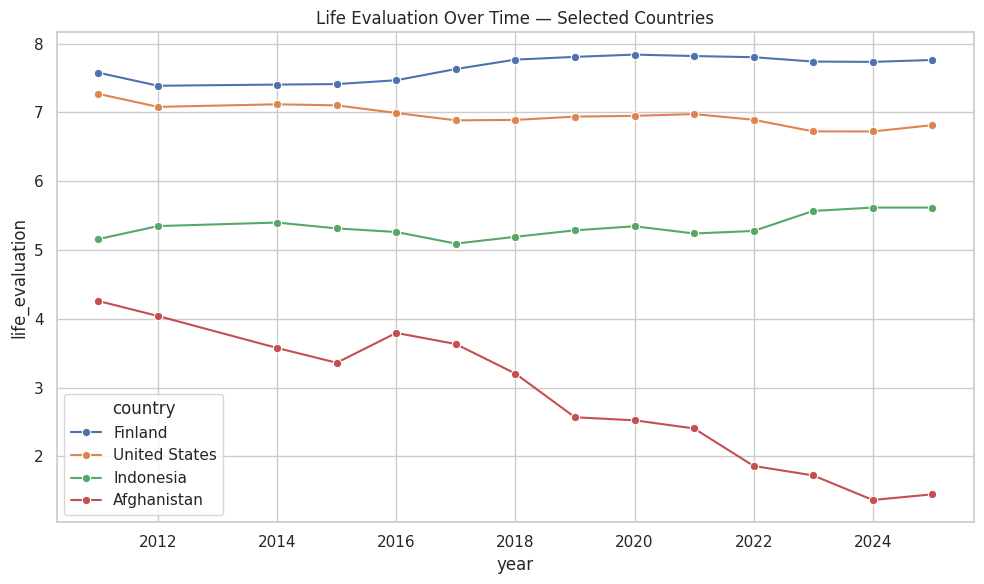

In [23]:
countries_of_interest = ["Finland", "United States", "Indonesia", "Afghanistan"]
subset = df[df["country"].isin(countries_of_interest)]

fig, ax = plt.subplots()
sns.lineplot(data=subset, x="year", y="life_evaluation", hue="country", marker="o", ax=ax)
ax.set_title("Life Evaluation Over Time — Selected Countries")
plt.tight_layout()
plt.savefig("../visuals/country_trends.png", dpi=150)
plt.show()


## 7. Biggest Movers: Who Improved or Declined the Most?

In [24]:
# Compare each country's earliest vs most recent available year (only countries with >=2 data points)
first_last = (
    df.sort_values("year")
    .groupby("country")
    .agg(first_year=("year", "first"), last_year=("year", "last"),
         first_score=("life_evaluation", "first"), last_score=("life_evaluation", "last"),
         n_years=("year", "nunique"))
)
first_last = first_last[first_last["n_years"] >= 2].copy()
first_last["change"] = first_last["last_score"] - first_last["first_score"]
first_last = first_last.sort_values("change", ascending=False)

print("Top 10 biggest improvers:")
display(first_last.head(10)[["first_year", "last_year", "first_score", "last_score", "change"]])

print("\nTop 10 biggest decliners:")
display(first_last.tail(10)[["first_year", "last_year", "first_score", "last_score", "change"]])


Top 10 biggest improvers:


,first_year,last_year,first_score,last_score,change
country,,,,,
Serbia,2011,2025,4.564,6.691,2.127
Bulgaria,2011,2025,3.889,5.703,1.814
Georgia,2011,2025,3.892,5.517,1.625
Latvia,2011,2025,4.762,6.365,1.603
Bosnia and Herzegovina,2011,2025,4.857,6.381,1.524
Kosovo,2011,2025,5.420,6.910,1.490
Romania,2011,2025,5.178,6.629,1.451
China,2011,2025,4.680,6.074,1.394
Philippines,2011,2025,4.825,6.206,1.381



Top 10 biggest decliners:


,first_year,last_year,first_score,last_score,change
country,,,,,
South Sudan,2015,2019,3.832,2.817,-1.015
Myanmar,2011,2025,5.322,4.287,-1.035
Turkmenistan,2011,2021,6.568,5.474,-1.094
Botswana,2011,2025,4.581,3.464,-1.117
Venezuela,2011,2025,6.922,5.756,-1.166
Jordan,2011,2025,5.706,4.478,-1.228
Syria,2011,2018,4.735,3.462,-1.273
Lebanon,2011,2025,5.049,3.723,-1.326
Malawi,2011,2025,4.624,3.284,-1.340


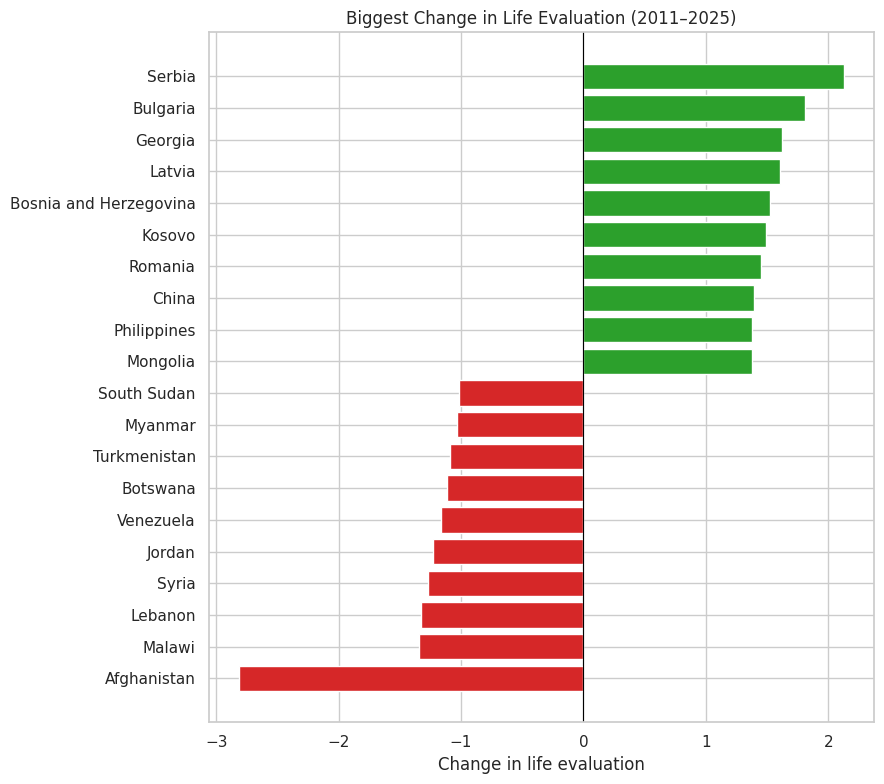

In [25]:
movers = pd.concat([first_last.head(10), first_last.tail(10)]).sort_values("change")

fig, ax = plt.subplots(figsize=(9, 8))
colors = movers["change"].apply(lambda x: "#2ca02c" if x > 0 else "#d62728")
ax.barh(movers.index, movers["change"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"Biggest Change in Life Evaluation ({first_last['first_year'].min()}–{first_last['last_year'].max()})")
ax.set_xlabel("Change in life evaluation")
plt.tight_layout()
plt.savefig("../visuals/biggest_movers.png", dpi=150)
plt.show()


## 8. Volatility: Which Countries Are Most/Least Stable?

In [26]:
volatility = df.groupby("country")["life_evaluation"].agg(["std", "count"])
volatility = volatility[volatility["count"] >= 5].sort_values("std", ascending=False)

print("Most volatile (top 10):")
display(volatility.head(10))

print("\nMost stable (bottom 10):")
display(volatility.tail(10))


Most volatile (top 10):


,std,count
country,,
Lebanon,1.047,14
Afghanistan,0.986,14
Venezuela,0.808,14
Angola,0.692,6
Serbia,0.666,14
Benin,0.621,14
Bulgaria,0.617,14
Sierra Leone,0.612,14
Guinea,0.594,14



Most stable (bottom 10):


,std,count
country,,
Bhutan,0.098,5
France,0.097,14
Israel,0.097,14
Japan,0.096,14
Denmark,0.091,14
Bolivia,0.088,14
Netherlands,0.084,14
Belgium,0.072,14
Hong Kong SAR of China,0.072,14


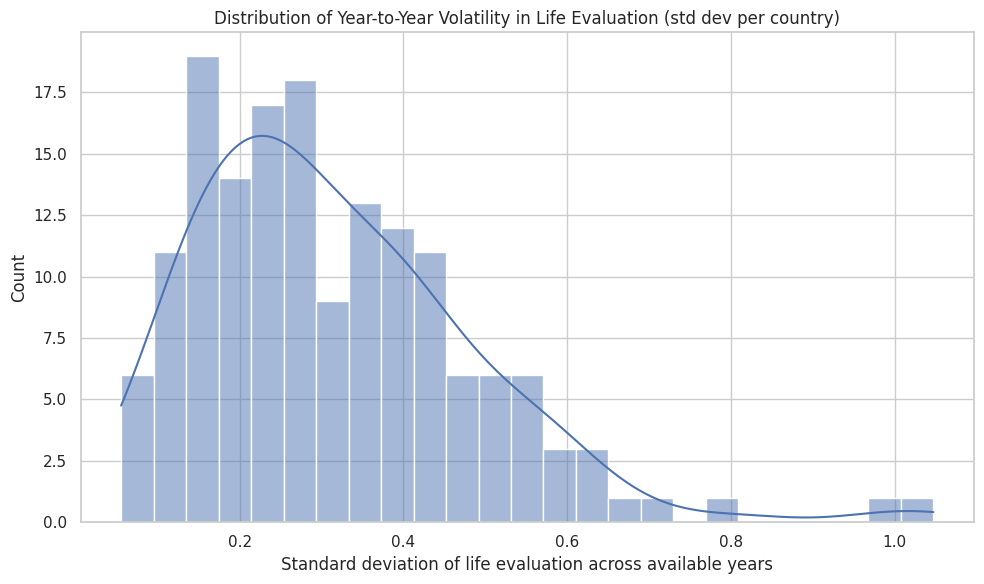

In [27]:
fig, ax = plt.subplots()
sns.histplot(volatility["std"], bins=25, kde=True, ax=ax)
ax.set_title("Distribution of Year-to-Year Volatility in Life Evaluation (std dev per country)")
ax.set_xlabel("Standard deviation of life evaluation across available years")
plt.tight_layout()
plt.savefig("../visuals/volatility_distribution.png", dpi=150)
plt.show()


## 9. Key Insights

- **Distribution:** 2025 life evaluation scores are left-skewed (skew = −0.61) — most countries
  cluster in the medium-high range (median 5.94 vs mean 5.65), with a long tail of lower-scoring
  countries pulling the mean down. The gap between the happiest country (Finland, 7.76) and the
  unhappiest (Afghanistan, 1.45) is 6.32 points — over 80% of the entire 0–10 scale.

- **Strongest simple correlate:** `social_support` has the highest simple correlation with
  happiness (r = 0.81, p < 0.001), ahead of `gdp_per_capita` (r = 0.75) and
  `healthy_life_expectancy` (r = 0.68). `generosity` is essentially uncorrelated (r = 0.04,
  p = 0.65) at the cross-country level.

- **Strongest independent predictor:** once all six factors are controlled for together
  (R² = 0.827, i.e. the model explains ~83% of cross-country variance), the ranking shifts.
  `freedom` has the largest independent effect (coef = 1.81, p < 0.001), followed by
  `social_support` (coef = 1.44, p < 0.001) and `healthy_life_expectancy` (coef = 0.91,
  p < 0.001). `gdp_per_capita` is still significant but smaller (coef = 0.49, p = 0.011).
  `corruption_perception` (p = 0.20) and `generosity` (p = 0.71) are **not** statistically
  significant once the other factors are accounted for — their raw correlation with happiness
  is likely explained by their overlap with GDP/social support, not an independent effect.
  This is the clearest illustration of why correlation ≠ independent contribution: GDP looked
  like the strongest story in Section 4's chart, but freedom and social support matter more
  once you control for everything else.

- **Trend:** the global average rose from 5.39 (2011) to 5.65 (2025) — a modest but
  statistically significant upward trend (slope = +0.019 points/year, R² = 0.76,
  p < 0.001). At that rate the global average has gained roughly a quarter of a point over
  14 years; the trend is real but slow, and not a dramatic global happiness boom.

- **Biggest movers:** Serbia improved the most (+2.13 points, 2011→2025), followed by
  Bulgaria (+1.81) and Georgia (+1.63) — all Eastern European/Balkan countries recovering
  from a low base. Afghanistan declined the most by far (−2.81 points), consistent with the
  conflict and Taliban takeover during this period; Malawi (−1.34), Lebanon (−1.33) and
  Syria (−1.27, civil war) also declined sharply. These are exactly the kind of numbers that
  deserve a one-line "why" in your own words — e.g. linking Lebanon's decline to its 2019–2021
  economic collapse — rather than just reporting the delta.

- **Volatility:** Lebanon (std = 1.05) and Afghanistan (std = 0.99) are the most volatile
  countries — unsurprising given the conflict/crisis context above. The most stable countries
  are all high-income, institutionally stable nations: Sweden (std = 0.06), Hong Kong
  (std = 0.07), Belgium (std = 0.07), and the Netherlands (std = 0.08) — happiness there
  barely moves year to year, which itself is a finding (stability may be as much a marker of
  strong institutions as the absolute happiness score).

## Limitations / Next Steps

- No `region`/`continent` column in the source data — a regional comparison would need an external country → region mapping (e.g. UN M49 or `pycountry-convert`).
- Regression here is linear and cross-sectional (2025 only); a panel/fixed-effects model would better separate within-country change from between-country differences.
- Correlation/regression still can't prove causation — omitted variables (e.g. culture, colonial history) may confound these relationships.
- The "Social media & happiness" theme of WHR 2026 isn't covered — the free Figure 2.1 data doesn't include social media variables.
